# All bands

This notebook is used to get a sense of the downloaded and aggregated bands for each scene over the AOI

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from dotenv import load_dotenv

from lulc.config import load_config
from lulc.io import GLOBAL_CONFIG, RAW_DATA_DIR
from lulc.viz.images import robust_plot

In [3]:
load_dotenv()
matplotlib.rc_file(matplotlib.matplotlib_fname())
cfg = load_config(GLOBAL_CONFIG)

In [4]:
file_name = (
    RAW_DATA_DIR
    / "DJF/S2B_MSIL2A_20220220T110959_N0510_R137_T30STG_20240516T171047_ALLBANDS.tif"
)

In [5]:
file_name

PosixPath('/Users/stepit/Repositories/projects/lulc-classification/data/raw/DJF/S2B_MSIL2A_20220220T110959_N0510_R137_T30STG_20240516T171047_ALLBANDS.tif')

In [6]:
!gdalinfo -stats {file_name}

Driver: GTiff/GeoTIFF
Files: /Users/stepit/Repositories/projects/lulc-classification/data/raw/DJF/S2B_MSIL2A_20220220T110959_N0510_R137_T30STG_20240516T171047_ALLBANDS.tif
       /Users/stepit/Repositories/projects/lulc-classification/data/raw/DJF/S2B_MSIL2A_20220220T110959_N0510_R137_T30STG_20240516T171047_ALLBANDS.tif.aux.xml
Size is 5169, 5181
Coordinate System is:
PROJCRS["WGS 84 / UTM zone 30N",
    BASEGEOGCRS["WGS 84",
        DATUM["World Geodetic System 1984",
            ELLIPSOID["WGS 84",6378137,298.257223563,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4326]],
    CONVERSION["UTM zone 30N",
        METHOD["Transverse Mercator",
            ID["EPSG",9807]],
        PARAMETER["Latitude of natural origin",0,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8801]],
        PARAMETER["Longitude of natural origin",-3,
            ANGLEUNIT["degree",0.017453

In [7]:
with rasterio.open(file_name, "r") as src:
    data = src.read()
    profile = src.profile
    bounds = src.bounds

In [8]:
data.shape

(11, 5181, 5169)

In [9]:
profile

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 5169, 'height': 5181, 'count': 11, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 30N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32630"]]'), 'transform': Affine(10.0, 0.0, 200780.0,
       0.0, -10.0, 4151040.0), 'blockxsize': 1024, 'blockysize': 1024, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}

In [10]:
profile["crs"], profile["transform"]

(CRS.from_wkt('PROJCS["WGS 84 / UTM zone 30N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32630"]]'),
 Affine(10.0, 0.0, 200780.0,
        0.0, -10.0, 4151040.0))

Text(0, 0.5, 'latitude [m]')

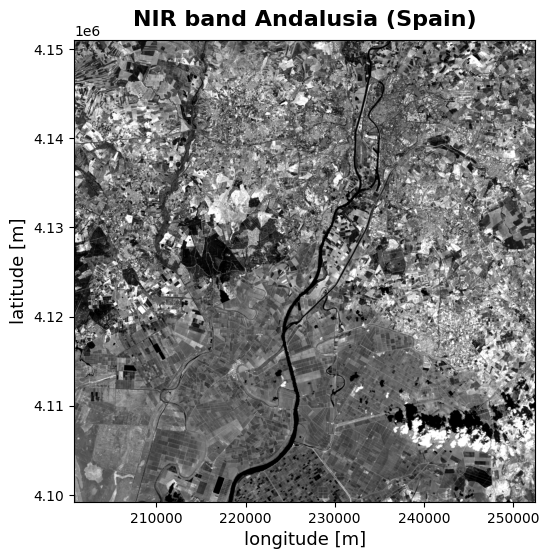

In [11]:
robust_plot(data[9], bounds)
plt.title("NIR band Andalusia (Spain)")
plt.xlabel("longitude [m]")
plt.ylabel("latitude [m]")

In [15]:
cfg.msi.band_names

{'B02_10m': 'blue',
 'B03_10m': 'green',
 'B04_10m': 'red',
 'B08_10m': 'nir',
 'B05_20m': 'red_edge1',
 'B06_20m': 'red_edge2',
 'B07_20m': 'red_edge3',
 'B8A_20m': 'narrow_nir',
 'B11_20m': 'swir1',
 'B12_20m': 'swir2',
 'SCL_20m': 'scl'}

In [13]:
def plot_bands(data, bands, bounds=None):
    n = data.shape[0]
    cols = math.ceil(math.sqrt(n))
    rows = math.ceil(n / cols)

    _, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).flatten()

    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top] if bounds else None

    for i, ax in enumerate(axes):
        if i >= n:
            ax.set_visible(False)
            continue
        band = data[i].astype(float)
        lo, hi = np.percentile(band[band > 0], [2, 98])
        ax.imshow(
            np.clip((band - lo) / (hi - lo), 0, 1),
            extent=extent,
            origin="upper",
            cmap="gray",
        )
        ax.set_title(f"Band {bands[i]}", fontsize=9)

    plt.tight_layout()

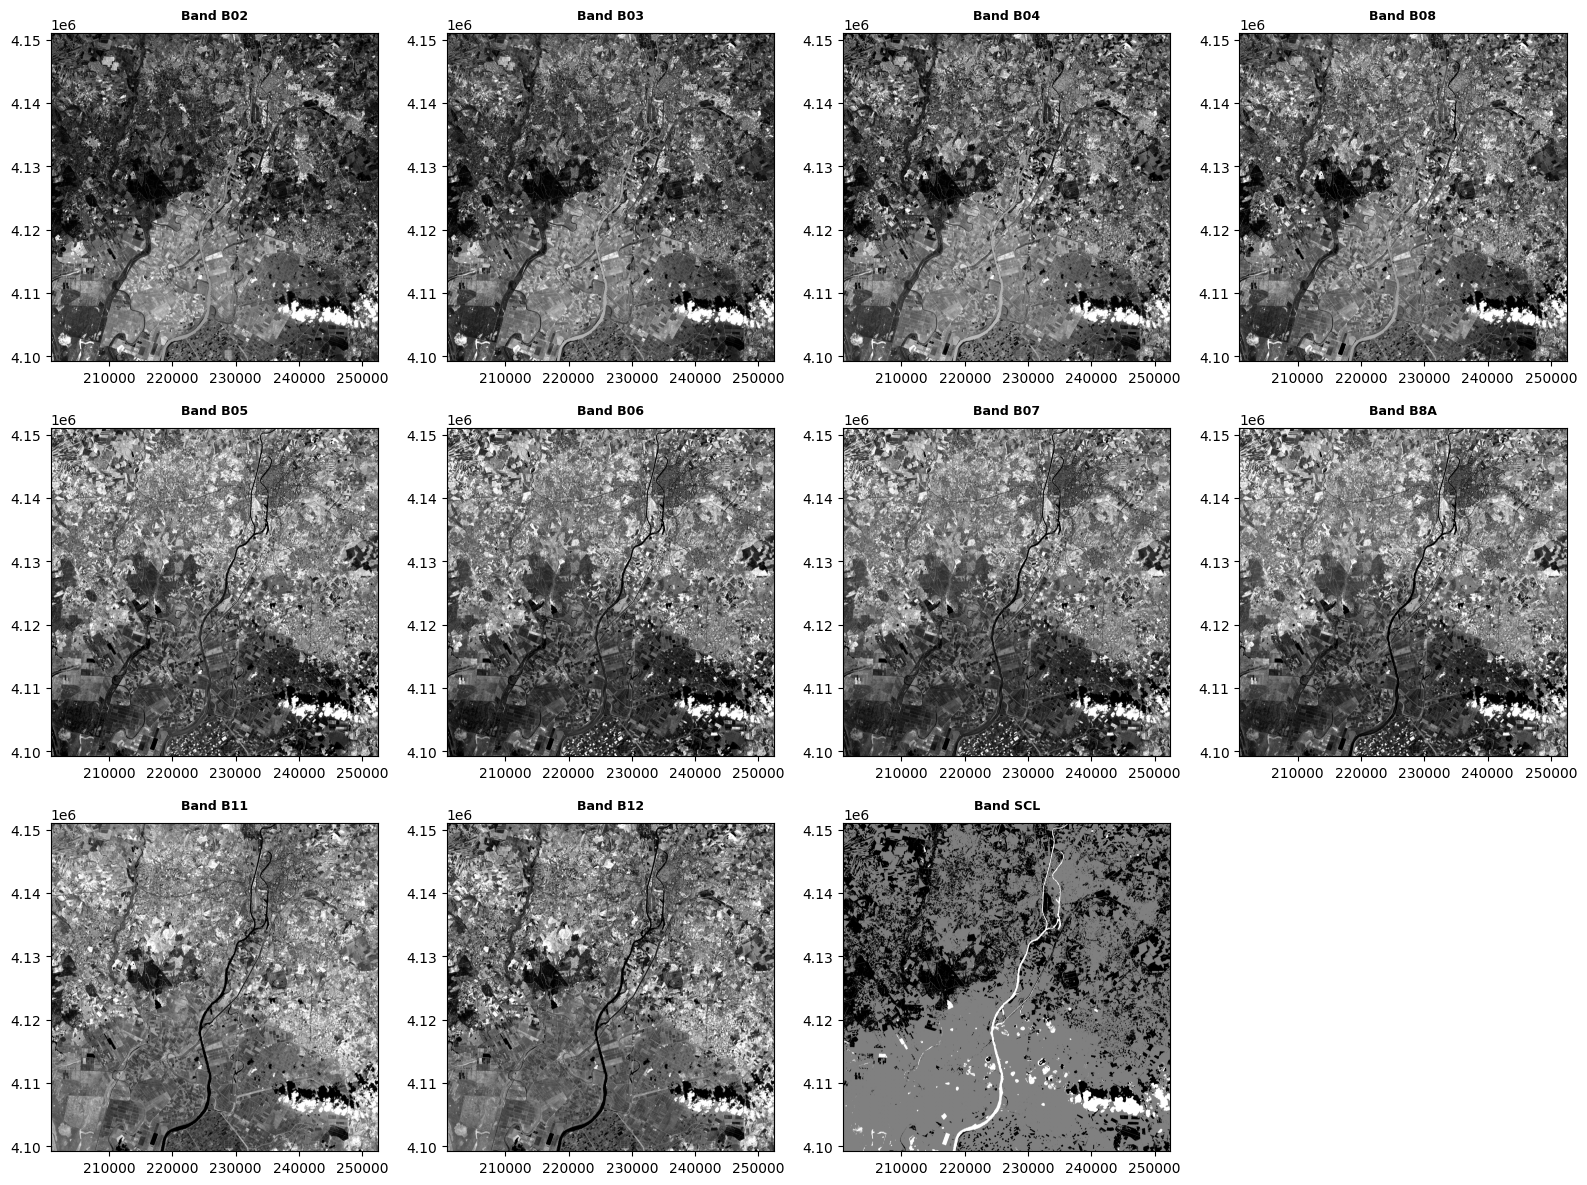

In [14]:
plot_bands(data, band_names, bounds)